C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Cluster Centers:
[[7.33333333 9.        ]
 [1.16666667 1.46666667]]

Labels:
[1 1 0 0 1 0]


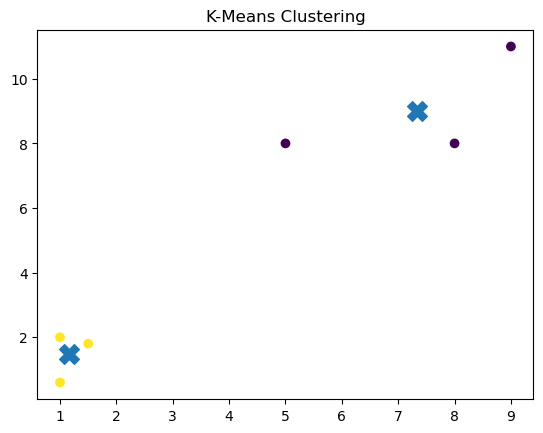

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

ValueError: n_samples=6 should be >= n_clusters=7.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

# ---------------------------------------------------
# Lab Experiment 1 : K-Means Clustering
# ---------------------------------------------------

X = np.array([
    [1,2],
    [1.5,1.8],
    [5,8],
    [8,8],
    [1,0.6],
    [9,11]
])

kmeans = KMeans(n_clusters=2, random_state=0)

kmeans.fit(X)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

print("\nLabels:")
print(kmeans.labels_)

plt.scatter(X[:,0], X[:,1], c=kmeans.labels_)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X'
)

plt.title("K-Means Clustering")
plt.show()

# ---------------------------------------------------
# Lab Experiment 2 : Elbow Method
# ---------------------------------------------------

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ---------------------------------------------------
# Lab Experiment 3 : Hierarchical Clustering
# ---------------------------------------------------

data = np.array([
    [5,3],
    [10,15],
    [15,12],
    [24,10],
    [30,30],
    [85,70],
    [71,80],
    [60,78],
    [70,55],
    [80,91]
])

linked = linkage(data, method='ward')

plt.figure(figsize=(8,5))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

# ---------------------------------------------------
# Lab Experiment 4 : Agglomerative Clustering Example
# ---------------------------------------------------

X, y = make_blobs(
    n_samples=100,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X)

plt.scatter(X[:,0], X[:,1], c=kmeans.labels_)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X'
)

plt.title("Agglomerative Style Cluster Visualization")
plt.show()